### Netflix Data Analysis (Mini Project)
This analysis is valuable for both Netflix and its audience. It helps viewers discover trends and popular content across countries and genres. Netflix can also use these insights to improve content strategy and recommendations.


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving netflix_titles.csv to netflix_titles.csv


Netflix Dataset

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('netflix_titles.csv')

# Display basic info
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


🔍 Dataset Overview

In [ ]:
# Basic info
df.info()

# Check for null values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


### Summary of Data Cleaning Steps:
- Removed duplicate records to avoid redundancy.
- Filled missing values in key columns using appropriate strategies.
- Converted date fields to datetime format for consistency.
- Stripped extra whitespace from string columns.


In [ ]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Not Specified')
df['cast'] = df['cast'].fillna('Not Specified')

df['director'].fillna('Not Specified', inplace=True)
df['cast'].fillna('Not Specified', inplace=True)
df.dropna(subset=['date_added'], inplace=True)

# Convert 'date_added' to datetime
# Strip extra spaces and convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='mixed')

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month


<ipython-input-5-34cb56976afe>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Not Specified', inplace=True)
<ipython-input-5-34cb56976afe>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

<ipython-input-6-5029158354bb>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


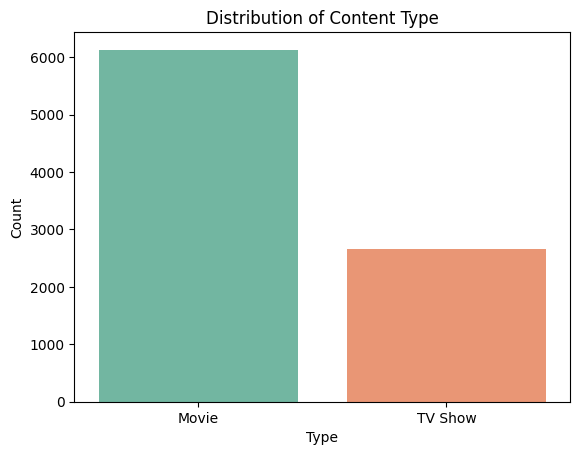

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='type', palette='Set2')
plt.title('Distribution of Content Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()


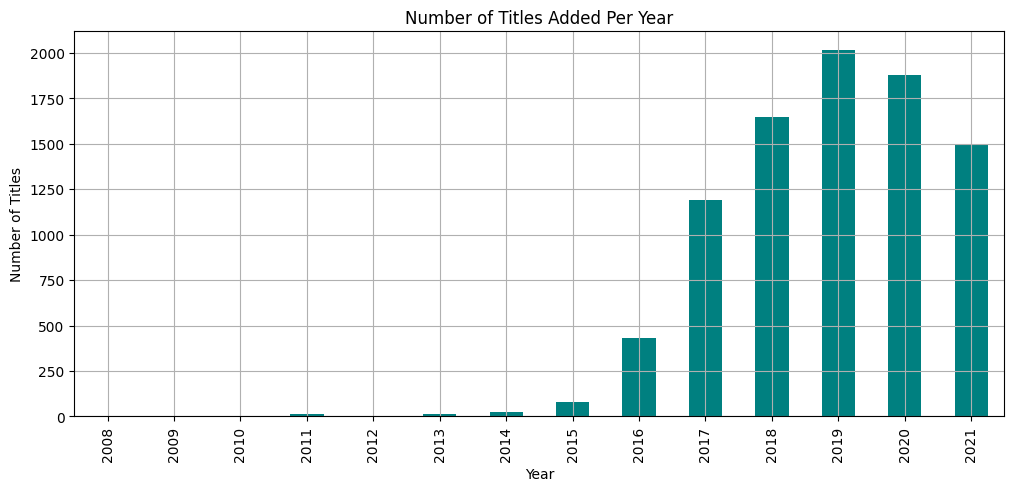

In [ ]:
df['year_added'].value_counts().sort_index().plot(kind='bar', figsize=(12, 5), color='teal')
plt.title('Number of Titles Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()


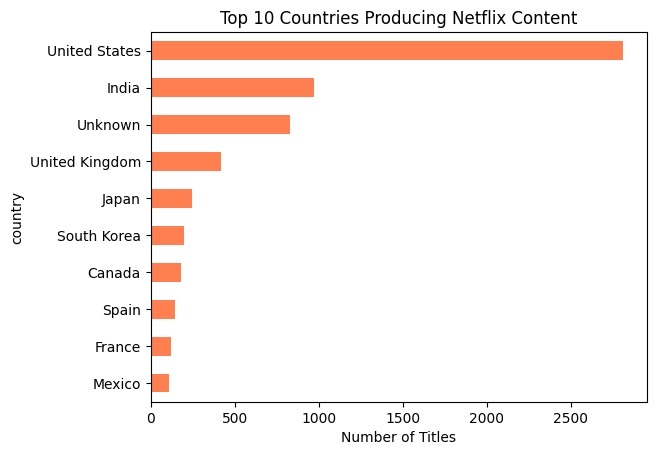

In [ ]:
top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind='barh', color='coral')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Number of Titles')
plt.gca().invert_yaxis()
plt.show()


🎭 Top 10 Actors Frequently Appearing in Netflix Titles

<ipython-input-12-5cd3fbc2ad3f>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_actors_df, x='Count', y='Actor', palette='coolwarm')


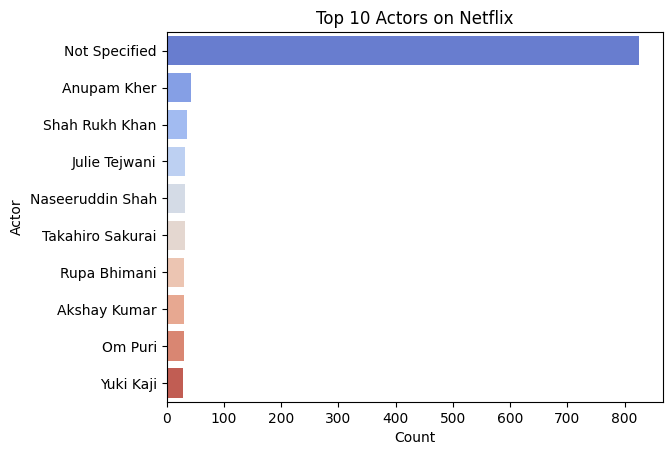

In [ ]:
from collections import Counter

# Get all cast members
all_cast = df['cast'].dropna().str.split(', ')
flat_cast = [actor for sublist in all_cast for actor in sublist]
top_actors = Counter(flat_cast).most_common(10)

# Convert to DataFrame
top_actors_df = pd.DataFrame(top_actors, columns=['Actor', 'Count'])

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=top_actors_df, x='Count', y='Actor', palette='coolwarm')
plt.title('Top 10 Actors on Netflix')
plt.show()


<ipython-input-9-f8e40e516a55>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_df, y='Genre', x='Count', palette='viridis')


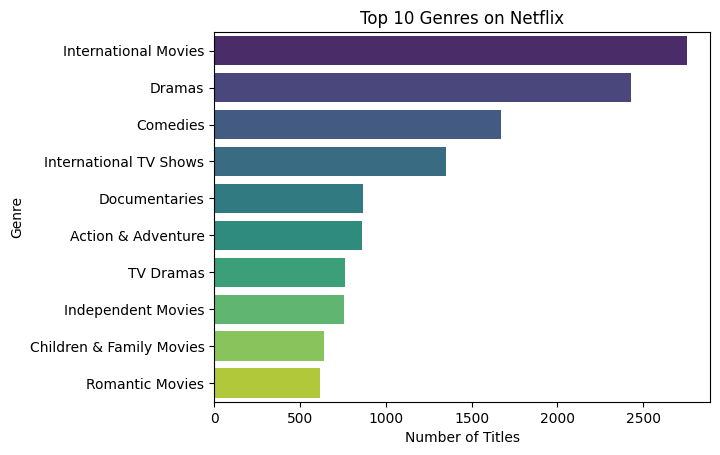

In [ ]:
from collections import Counter

genre_list = df['listed_in'].str.split(', ')
flat_genres = [genre for sublist in genre_list.dropna() for genre in sublist]
genre_counts = Counter(flat_genres).most_common(10)

# Convert to DataFrame
genre_df = pd.DataFrame(genre_counts, columns=['Genre', 'Count'])
sns.barplot(data=genre_df, y='Genre', x='Count', palette='viridis')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()


📅 Monthly Trends in Netflix Content Additions

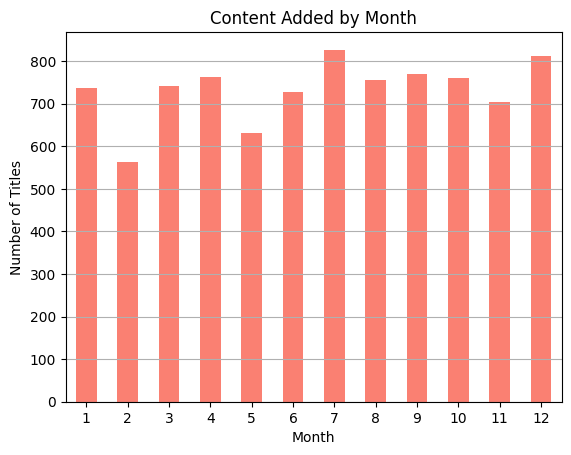

In [ ]:
monthly_additions = df['month_added'].value_counts().sort_index()
monthly_additions.plot(kind='bar', color='salmon')
plt.title('Content Added by Month')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


📈 Predicting Future Netflix Releases (2025, 2026) with Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
year_data = df['year_added'].value_counts().sort_index()
X = np.array(year_data.index).reshape(-1, 1)
y = year_data.values

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict for future years
future_years = np.array([[2025], [2026]])
predicted = model.predict(future_years)

print(f"Predicted titles in 2025: {int(predicted[0])}")
print(f"Predicted titles in 2026: {int(predicted[1])}")


Predicted titles in 2025: 2403
Predicted titles in 2026: 2572


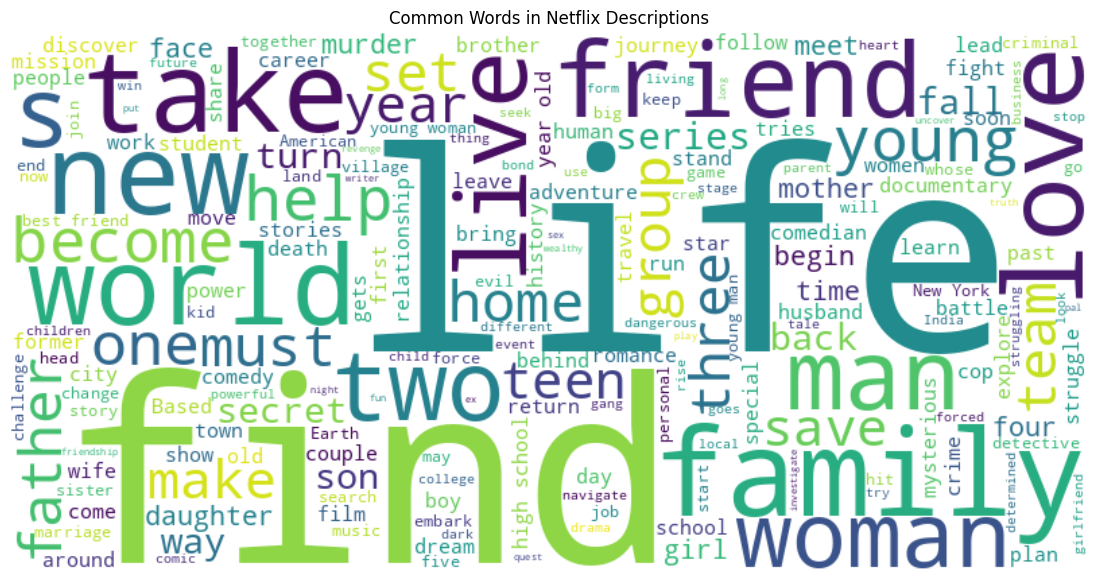

In [ ]:
from wordcloud import WordCloud

text = ' '.join(df['description'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Netflix Descriptions')
plt.show()


### Each cluster groups together titles with similar genres. For example, Cluster 0 may include comedy-heavy content, while Cluster 1 might lean towards dramas or thrillers. This helps identify genre-based groupings on Netflix.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Genre clustering
df['listed_in'] = df['listed_in'].fillna('')
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(df['listed_in'])

kmeans = KMeans(n_clusters=3, random_state=42)
df['genre_cluster'] = kmeans.fit_predict(X)

# Display cluster distribution
df['genre_cluster'].value_counts()


,count
genre_cluster,
1,4921
0,3007
2,869


🧪 Recommendation System Code

### 🎯 Simple Content-Based Recommendation System
We use cosine similarity on TF-IDF vectors of descriptions to recommend similar shows or movies.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
# Fill NaNs with empty string
df['description'] = df['description'].fillna('')

# Vectorize descriptions
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['description'])

# Compute similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)


### How to Use the Recommendation System:
Enter a title from the dataset as input to get similar titles based on description similarity.

For example: `get_recommendations('Narcos')`


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Fill missing values
df['description'] = df['description'].fillna('')
df['director'] = df['director'].fillna('')
df['cast'] = df['cast'].fillna('')
df['rating'] = df['rating'].fillna('')

# Create a combined string for each record
df['combined_features'] = (
    df['description'] + ' ' +
    df['director'] + ' ' +
    df['cast'] + ' ' +
    df['rating']
)

# Vectorize combined text
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined_features'])


NameError: name 'df' is not defined

In [ ]:
# Reset index to get title lookup
df = df.reset_index()

# Title-based recommendation
def get_recommendations(title, cosine_sim=cosine_sim):
    indices = pd.Series(df.index, index=df['title']).drop_duplicates()
    idx = indices.get(title)

    if idx is None:
        return f"No match found for '{title}'"

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]
    movie_indices = [i[0] for i in sim_scores]
    return df['title'].iloc[movie_indices]


In [ ]:
get_recommendations("Sherlock Holmes")


,title
8067,Spy Kids 3: Game Over
3836,In Family I Trust
4997,Borderliner
8023,Skiptrace
7486,Monster High: Fright On!


### 🌍 Netflix Global Content Map
This interactive map visualizes the number of titles available from each country on Netflix.


In [ ]:
!pip install plotly


In [ ]:
import plotly.express as px

# Count titles per country (many rows have multiple countries separated by ', ')
df['country_cleaned'] = df['country'].str.split(',').str[0]  # take only the first country for simplicity

country_counts = df['country_cleaned'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']


In [ ]:
fig = px.choropleth(country_counts,
                    locations='Country',
                    locationmode='country names',
                    color='Count',
                    color_continuous_scale='Reds',
                    title='🌍 Netflix Content by Country')
fig.show()


## 🎬 Genre-Based Recommendation Engine

In this section, we build a simple yet effective recommendation engine that suggests similar Netflix titles based on genre similarity.

### 📌 Approach:
We use the `listed_in` column (which contains genres like Drama, Comedy, Action, etc.) to find similar content. The steps involved are:

1. **TF-IDF Vectorization**:
   - Convert genre strings into numerical format using `TfidfVectorizer` to handle multi-genre text data.

2. **Cosine Similarity**:
   - Calculate the cosine similarity between all content items based on their TF-IDF genre vectors.

3. **Recommendation Function**:
   - Create a reusable function that takes a title as input and returns the top 10 most similar titles based on genre.

This approach allows us to group and recommend content with similar genre patterns, which can help users explore more titles they’re likely to enjoy.

### ✅ Example Usage:
```python
genre_based_recommendation("Breaking Bad")


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['listed_in'])


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

genre_similarity = cosine_similarity(tfidf_matrix)


In [ ]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()


In [ ]:
def genre_based_recommendation(title, cosine_sim=genre_similarity):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]  # top 10 similar
    content_indices = [i[0] for i in sim_scores]
    return df[['title', 'listed_in']].iloc[content_indices]


In [ ]:
genre_based_recommendation("Breaking Bad")


,title,listed_in
1477,Dare Me,"Crime TV Shows, TV Dramas, TV Thrillers"
1980,The Blacklist,"Crime TV Shows, TV Dramas, TV Thrillers"
2767,Ozark,"Crime TV Shows, TV Dramas, TV Thrillers"
3762,Designated Survivor,"Crime TV Shows, TV Dramas, TV Thrillers"
5940,Breaking Bad,"Crime TV Shows, TV Dramas, TV Thrillers"
8387,The Lizzie Borden Chronicles,"Crime TV Shows, TV Dramas, TV Thrillers"
714,Beyond Evil,"Crime TV Shows, International TV Shows, TV Thr..."
668,Hap and Leonard,"Crime TV Shows, TV Dramas"
921,StartUp,"Crime TV Shows, TV Dramas"
1933,Wentworth,"Crime TV Shows, TV Dramas"
